# Agricultural Futures Final Project

## Strategy Evaluation Notebook

This notebook assumes the data engineering work is already complete.

Prepared inputs:
- [corn_futures_data_builder.ipynb](./corn_futures_data_builder.ipynb)
- [wheat_futures_data_builder.ipynb](./wheat_futures_data_builder.ipynb)
- [mod13a2_ndvi_data_builder.ipynb](./mod13a2_ndvi_data_builder.ipynb)

Notebook flow:
1. load the prepared corn, wheat, and NDVI data
2. treat the NASA NDVI regime as its own directional signal
3. build and evaluate each strategy family in its own section
4. test whether the NDVI regime improves selected directional strategies
5. compare all standalone and regime-filtered sleeves before building a combined portfolio

In [1]:
from pathlib import Path
import os
import warnings
from itertools import product


def locate_project_root():
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data_ag_futures').exists() and (candidate / 'notebooks_ag_futures').exists():
            return candidate
    raise FileNotFoundError('Could not locate a project root containing data_ag_futures and notebooks_ag_futures.')


PROJECT_ROOT = locate_project_root()
NOTEBOOKS_ROOT = PROJECT_ROOT / 'notebooks_ag_futures'
os.environ.setdefault('MPLCONFIGDIR', str(NOTEBOOKS_ROOT / '.mplconfig'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from IPython.display import Markdown, display

warnings.filterwarnings('ignore', category=FutureWarning)

DATA_ROOT = PROJECT_ROOT / 'data_ag_futures'
PROCESSED_DIR = DATA_ROOT / 'processed'

CORN_CACHE_PATH = PROCESSED_DIR / 'corn_continuous_back_adjusted.csv'
WHEAT_CACHE_PATH = PROCESSED_DIR / 'wheat_continuous_back_adjusted.csv'
NDVI_LEVEL_CACHE_PATH = PROCESSED_DIR / 'mod13a2_ndvi_level_series.csv'
NDVI_DAILY_CACHE_PATH = PROCESSED_DIR / 'mod13a2_ndvi_daily_series.csv'

MA_PAIRS = [(10, 30), (30, 100), (80, 160)]
PRIMARY_PAIR = (30, 100)
PAIRS_HORIZONS = (5, 10, 20)
RUN_WHEAT_PAIRS_ANALYSIS = True
REGIME_NEUTRAL_SCALE = 0.5


def annualized_sharpe(returns, periods=252):
    series = pd.Series(returns).dropna()
    if series.empty or series.std() == 0:
        return np.nan
    return np.sqrt(periods) * series.mean() / series.std()


def max_drawdown(returns):
    series = pd.Series(returns).fillna(0.0)
    wealth = (1.0 + series).cumprod()
    drawdown = wealth / wealth.cummax() - 1.0
    return drawdown.min()


def summarize_strategy(name, returns, signal=None):
    series = pd.Series(returns).dropna()
    if series.empty:
        cum_return = np.nan
        ann_vol = np.nan
        mdd = np.nan
    else:
        cum_return = (1.0 + series).prod() - 1.0
        ann_vol = series.std() * np.sqrt(252)
        mdd = max_drawdown(series)
    summary = {
        'strategy': name,
        'obs': int(series.shape[0]),
        'cum_return': cum_return,
        'ann_sharpe': annualized_sharpe(series),
        'ann_vol': ann_vol,
        'max_drawdown': mdd,
    }
    if signal is not None:
        sig = pd.Series(signal).dropna()
        summary['active_share'] = sig.abs().mean() if not sig.empty else np.nan
    return summary


def summary_table(rows, sort=False):
    frame = pd.DataFrame(rows).set_index('strategy')
    if sort:
        frame = frame.sort_values('ann_sharpe', ascending=False)
    return frame.round(4)


def cumulative_return(returns):
    series = pd.Series(returns).fillna(0.0)
    return (1.0 + series).cumprod() - 1.0


def plot_cumulative_returns(frame, title, figsize=(12, 6), linewidth=2.0, ncol=2):
    fig, ax = plt.subplots(figsize=figsize)
    for column in frame.columns:
        cumulative_return(frame[column]).plot(ax=ax, label=column, linewidth=linewidth)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(ncol=ncol)
    plt.tight_layout()
    plt.show()


def display_bullets(title, lines):
    body = '\n'.join(f'- {line}' for line in lines)
    display(Markdown(f'### {title}\n{body}'))


def require_file(path, label):
    if not path.exists():
        raise FileNotFoundError(f'{label} not found at {path}. Build it in the corresponding data-builder notebook first.')
    return path


def load_futures_cache(path, label):
    require_file(path, label)
    frame = pd.read_csv(path, parse_dates=['Date']).set_index('Date').sort_index()
    required = ['Open', 'High', 'Low', 'Close', 'Adj_Close_Futures', 'futures_ret']
    missing = [column for column in required if column not in frame.columns]
    if missing:
        raise ValueError(f'{label} cache is missing required columns: {missing}')
    return frame


def load_ndvi_caches(level_path, daily_path):
    require_file(level_path, 'NDVI level cache')
    require_file(daily_path, 'NDVI daily cache')
    ndvi_level = pd.read_csv(level_path, parse_dates=['date']).set_index('date').sort_index()
    ndvi_daily = pd.read_csv(daily_path, parse_dates=['Date']).set_index('Date').sort_index()
    required_daily = ['ndvi', 'ndvi_roll_mean', 'ndvi_roll_std', 'ndvi_z', 'ndvi_regime']
    missing = [column for column in required_daily if column not in ndvi_daily.columns]
    if missing:
        raise ValueError(f'NDVI daily cache is missing required columns: {missing}')
    level_overlay = ndvi_daily.reindex(ndvi_level.index)[['ndvi_roll_mean', 'ndvi_roll_std', 'ndvi_z', 'ndvi_regime']]
    ndvi_level = ndvi_level.join(level_overlay, how='left')
    return ndvi_level, ndvi_daily


def add_ma_signals(frame, pairs):
    data = frame.copy()
    daily_pct = data['Adj_Close_Futures'].pct_change()
    for short_window, long_window in pairs:
        short_col = f'ma{short_window}'
        long_col = f'ma{long_window}'
        signal_col = f'signal_{short_window}_{long_window}'
        strat_col = f'strategy_ret_{short_window}_{long_window}'
        data[short_col] = daily_pct.rolling(short_window).mean()
        data[long_col] = daily_pct.rolling(long_window).mean()
        signal = pd.Series(
            np.where(data[short_col] > data[long_col], 1.0, -1.0),
            index=data.index,
            dtype='float64',
        )
        signal[data[short_col].isna() | data[long_col].isna()] = np.nan
        data[signal_col] = signal
        data[strat_col] = data[signal_col].shift(1) * data['futures_ret']
    return data


def build_signal_strategy(signal, futures_ret, lag=1):
    signal = pd.Series(signal, dtype='float64')
    futures_ret = pd.Series(futures_ret).reindex(signal.index)
    returns = signal.shift(lag) * futures_ret
    return pd.DataFrame({'signal': signal, 'strategy_return': returns})


def apply_regime_filter(signal, regime, neutral_scale=REGIME_NEUTRAL_SCALE):
    signal = pd.Series(signal, dtype='float64')
    regime = pd.Series(regime, dtype='float64').reindex(signal.index)
    filtered = pd.Series(np.nan, index=signal.index, dtype='float64')
    flat_mask = signal.eq(0.0)
    filtered.loc[flat_mask] = 0.0
    active_mask = signal.notna() & regime.notna() & ~flat_mask
    filtered.loc[active_mask] = np.where(
        regime.loc[active_mask] == np.sign(signal.loc[active_mask]),
        signal.loc[active_mask],
        np.where(regime.loc[active_mask] == 0.0, neutral_scale * signal.loc[active_mask], 0.0),
    )
    return filtered


def run_countertrend_strategy(frame, p=2.2, avg_range_window=20, prior_high_window=20):
    data = frame[['Open', 'High', 'Low', 'Close', 'Adj_Close_Futures', 'futures_ret']].copy()
    data['DayRange'] = data['High'] - data['Low']
    data['Av20R'] = data['DayRange'].shift(1).rolling(avg_range_window).mean()
    data['PrvHiWRoll'] = data['High'].shift(1).rolling(prior_high_window).max()
    data['HitLevel'] = data['PrvHiWRoll'] - (p * data['Av20R'])
    data['Hit?'] = data['Low'] < data['HitLevel']
    data['HitAt'] = np.where(data['Open'] < data['HitLevel'], data['Open'], data['HitLevel'])
    data['HitAt'] = np.where(data['Hit?'], data['HitAt'], np.nan)
    data['ExitPr'] = data['Close']
    data['strategy_return'] = np.where(data['Hit?'], (data['ExitPr'] - data['HitAt']) / data['HitAt'], 0.0)
    data['signal'] = np.where(data['Hit?'], 1.0, 0.0)
    return data


def run_vol_regime_strategy(frame, vol_window=20, z_window=250, neutral_low=0.0, neutral_high=0.5):
    data = frame[['futures_ret']].copy()
    data['vol20'] = data['futures_ret'].rolling(vol_window).std()
    mean_ref = data['vol20'].shift(1).rolling(z_window).mean()
    std_ref = data['vol20'].shift(1).rolling(z_window).std()
    data['zvol20'] = (data['vol20'] - mean_ref) / std_ref
    data['signal'] = np.where((data['zvol20'] < neutral_low) | (data['zvol20'] > neutral_high), 1.0, -1.0)
    data.loc[data['zvol20'].isna(), 'signal'] = np.nan
    data['strategy_return'] = data['signal'].shift(1) * data['futures_ret']
    return data


def dickey_fuller_diagnostics(spread):
    series = pd.Series(spread).dropna()
    test = pd.DataFrame({'spread': series})
    test['delta_spread'] = test['spread'].diff()
    test['lag_spread'] = test['spread'].shift(1)
    test = test.dropna()
    model = sm.OLS(test['delta_spread'], sm.add_constant(test['lag_spread'])).fit()
    adf_stat, pvalue, n_lags, n_obs, critical_values, _ = adfuller(series, regression='c', autolag='AIC')
    return {
        'df_tstat_regression': float(model.tvalues['lag_spread']),
        'adf_stat': float(adf_stat),
        'pvalue': float(pvalue),
        'critical_10pct': critical_values['10%'],
        'critical_5pct': critical_values['5%'],
        'critical_1pct': critical_values['1%'],
        'observations': int(n_obs),
    }


def build_pairs_panel(corn_frame, wheat_frame, horizons=PAIRS_HORIZONS):
    pair = pd.DataFrame({
        'corn': corn_frame['Adj_Close_Futures'],
        'wheat': wheat_frame['Adj_Close_Futures'],
    }).dropna().copy()
    pair['spread_price'] = pair['corn'] - pair['wheat']
    pair['ret1CORN'] = pair['corn'].pct_change()
    pair['ret1WHEAT'] = pair['wheat'].pct_change()
    for horizon in horizons:
        for label in ['CORN', 'WHEAT']:
            price_col = 'corn' if label == 'CORN' else 'wheat'
            pair[f'{label}_ret{horizon}'] = pair[price_col].pct_change(horizon)
            pair[f'z{label}{horizon}'] = (
                (pair[f'{label}_ret{horizon}'] - pair[f'{label}_ret{horizon}'].shift(1).rolling(60).mean())
                / pair[f'{label}_ret{horizon}'].shift(1).rolling(60).std()
            )
        pair[f'zdiff{horizon}'] = pair[f'zCORN{horizon}'] - pair[f'zWHEAT{horizon}']
    pair['vol20CORN'] = pair['ret1CORN'].rolling(20).std()
    pair['vol20WHEAT'] = pair['ret1WHEAT'].rolling(20).std()
    pair['invvolCORN'] = 1.0 / pair['vol20CORN']
    pair['invvolWHEAT'] = 1.0 / pair['vol20WHEAT']
    pair['sum_invvol'] = pair['invvolCORN'] + pair['invvolWHEAT']
    pair['wCORN'] = pair['invvolCORN'] / pair['sum_invvol']
    pair['wWHEAT'] = pair['invvolWHEAT'] / pair['sum_invvol']
    pair['future_spread_ret'] = pair['wCORN'] * pair['ret1CORN'].shift(-1) - pair['wWHEAT'] * pair['ret1WHEAT'].shift(-1)
    return pair


def run_pairs_position_strategy(spread_col, fret1, long_entry=-1.0, short_entry=1.0, long_cap=1.0, short_cap=-1.0, max_holding=5):
    age = 0
    ages = []
    positions = []
    current_position = 0
    for spread in spread_col:
        if current_position == 1 and (spread >= long_cap or age >= max_holding):
            current_position = 0
            age = 0
        elif current_position == -1 and (spread <= short_cap or age >= max_holding):
            current_position = 0
            age = 0
        if current_position == 0:
            if spread <= long_entry:
                current_position = 1
                age = 1
            elif spread >= short_entry:
                current_position = -1
                age = 1
        else:
            age += 1
        ages.append(age)
        positions.append(current_position)
    results = pd.DataFrame({'position': positions, 'age': ages}, index=pd.Index(spread_col.index))
    results['strategy_return'] = results['position'] * fret1
    return results


def register_strategy(name, returns, signal=None):
    strategy_return_streams[name] = pd.Series(returns).rename(name)
    strategy_summary_map[name] = summarize_strategy(name, returns, signal)

Matplotlib is building the font cache; this may take a moment.


## Prepare data

Load the prepared corn, wheat, and NDVI caches and define the aligned corn-NDVI panel that will be reused in the strategy sections below.

In [2]:
corn = load_futures_cache(CORN_CACHE_PATH, 'corn futures cache')
corn = add_ma_signals(corn, MA_PAIRS)
ndvi_level, ndvi_daily = load_ndvi_caches(NDVI_LEVEL_CACHE_PATH, NDVI_DAILY_CACHE_PATH)
corn_ndvi = corn.join(ndvi_daily[['ndvi', 'ndvi_roll_mean', 'ndvi_roll_std', 'ndvi_z', 'ndvi_regime']], how='inner')

wheat = load_futures_cache(WHEAT_CACHE_PATH, 'wheat futures cache') if RUN_WHEAT_PAIRS_ANALYSIS and WHEAT_CACHE_PATH.exists() else None

strategy_return_streams = {}
strategy_summary_map = {}
register_strategy('buy_and_hold', corn['futures_ret'])

data_rows = [
    {
        'dataset': 'corn futures',
        'rows': len(corn),
        'start': corn.index.min().date(),
        'end': corn.index.max().date(),
    },
    {
        'dataset': 'ndvi level',
        'rows': len(ndvi_level),
        'start': ndvi_level.index.min().date(),
        'end': ndvi_level.index.max().date(),
    },
    {
        'dataset': 'ndvi daily',
        'rows': len(ndvi_daily),
        'start': ndvi_daily.index.min().date(),
        'end': ndvi_daily.index.max().date(),
    },
    {
        'dataset': 'corn + ndvi overlap',
        'rows': len(corn_ndvi),
        'start': corn_ndvi.index.min().date(),
        'end': corn_ndvi.index.max().date(),
    },
]
if wheat is not None:
    data_rows.append(
        {
            'dataset': 'wheat futures',
            'rows': len(wheat),
            'start': wheat.index.min().date(),
            'end': wheat.index.max().date(),
        }
    )

display(pd.DataFrame(data_rows))

display_bullets(
    'Data notes',
    [
        f'The NDVI-aligned corn sample runs from {corn_ndvi.index.min().date()} to {corn_ndvi.index.max().date()}.',
        'The NASA regime will be evaluated both as a standalone signal and as a reusable filter on corn strategy families.',
        'The wheat cache is available for the pairs section.' if wheat is not None else 'The wheat cache is missing, so the pairs section will be skipped.'
    ],
)

,dataset,rows,start,end
0,corn futures,6452,2000-07-17,2026-04-30
1,ndvi level,602,2000-02-18,2026-04-07
2,ndvi daily,9546,2000-02-18,2026-04-07
3,corn + ndvi overlap,6435,2000-07-17,2026-04-07
4,wheat futures,6464,2000-07-17,2026-04-30


### Data notes
- The NDVI-aligned corn sample runs from 2000-07-17 to 2026-04-07.
- The NASA regime will be evaluated both as a standalone signal and as a reusable filter on corn strategy families.
- The wheat cache is available for the pairs section.

## NASA regime signal: create signal

Treat the NASA vegetation regime as its own daily long-short-neutral signal on corn futures before using it as a regime filter on other strategies.

In [3]:
ndvi_strategy = build_signal_strategy(corn_ndvi['ndvi_regime'], corn_ndvi['futures_ret'], lag=1)
register_strategy('ndvi_regime', ndvi_strategy['strategy_return'], ndvi_strategy['signal'])

ndvi_summary = summary_table([
    summarize_strategy('buy_and_hold_overlap', corn_ndvi['futures_ret']),
    summarize_strategy('ndvi_regime', ndvi_strategy['strategy_return'], ndvi_strategy['signal']),
])

## NASA regime signal: evaluate

First inspect the NDVI series and regime states, then compare the regime signal with simple corn buy-and-hold over the overlapping sample.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold_overlap,6434,1.4893,0.2708,0.3080,-0.6644,NaN
ndvi_regime,6434,19.7722,0.5893,0.2574,-0.5415,0.6782


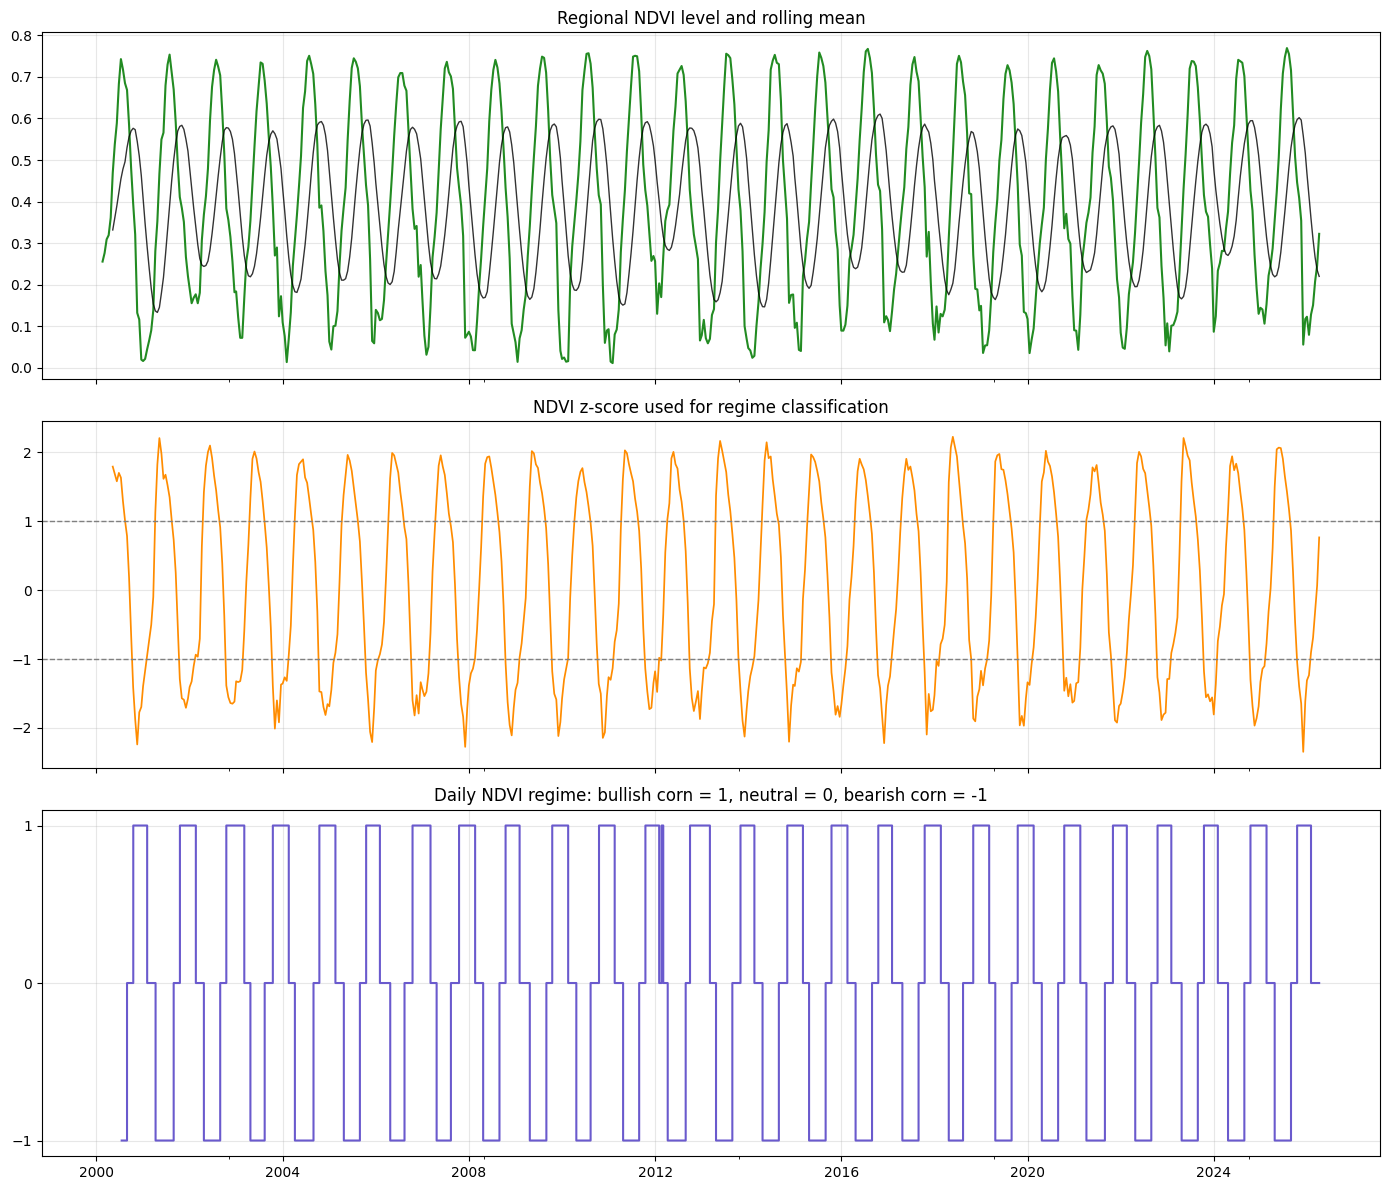

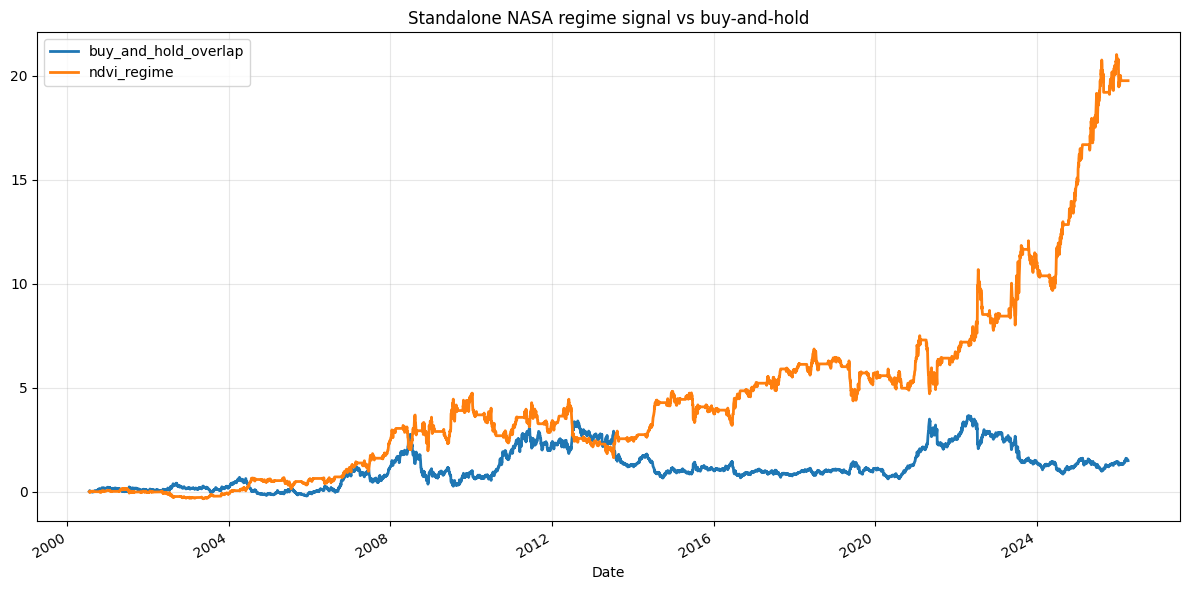

### Interpretation
- The NDVI regime is bullish 32.9% of the time, neutral 32.2%, and bearish 34.9%.
- As a standalone signal, NDVI posts an annualized Sharpe of 0.59.
- This regime will now be reused as a slow overlay on the directional corn strategies.

In [4]:
display(ndvi_summary)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
ndvi_level['ndvi'].plot(ax=axes[0], color='forestgreen', linewidth=1.5)
ndvi_level['ndvi_roll_mean'].plot(ax=axes[0], color='black', linewidth=1.0, alpha=0.8)
axes[0].set_title('Regional NDVI level and rolling mean')
axes[0].grid(True, alpha=0.3)

ndvi_level['ndvi_z'].plot(ax=axes[1], color='darkorange', linewidth=1.25)
axes[1].axhline(-1.0, color='gray', linestyle='--', linewidth=1)
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('NDVI z-score used for regime classification')
axes[1].grid(True, alpha=0.3)

axes[2].step(corn_ndvi.index, corn_ndvi['ndvi_regime'], where='post', color='slateblue')
axes[2].set_title('Daily NDVI regime: bullish corn = 1, neutral = 0, bearish corn = -1')
axes[2].set_yticks([-1, 0, 1])
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_cumulative_returns(
    pd.DataFrame({
        'buy_and_hold_overlap': corn_ndvi['futures_ret'],
        'ndvi_regime': ndvi_strategy['strategy_return'],
    }),
    'Standalone NASA regime signal vs buy-and-hold',
    figsize=(12, 6),
    ncol=1,
)

regime_shares = corn_ndvi['ndvi_regime'].value_counts(normalize=True).reindex([1.0, 0.0, -1.0]).fillna(0.0)
display_bullets(
    'Interpretation',
    [
        f'The NDVI regime is bullish {regime_shares.loc[1.0]:.1%} of the time, neutral {regime_shares.loc[0.0]:.1%}, and bearish {regime_shares.loc[-1.0]:.1%}.',
        f'As a standalone signal, NDVI posts an annualized Sharpe of {ndvi_summary.loc["ndvi_regime", "ann_sharpe"]:.2f}.',
        'This regime will now be reused as a slow overlay on the directional corn strategies.'
    ],
)

## Trend strategies: create signals

Build the three moving-average rules used in class and register each one as a standalone corn strategy sleeve.

In [5]:
trend_rows = [summarize_strategy('buy_and_hold', corn['futures_ret'])]
trend_names = []

for short_window, long_window in MA_PAIRS:
    name = f'ma_{short_window}_{long_window}'
    signal_col = f'signal_{short_window}_{long_window}'
    return_col = f'strategy_ret_{short_window}_{long_window}'
    trend_names.append(name)
    register_strategy(name, corn[return_col], corn[signal_col])
    trend_rows.append(summarize_strategy(name, corn[return_col], corn[signal_col]))

trend_summary = summary_table(trend_rows)

## Trend strategies: evaluate

Compare the three moving-average sleeves against corn buy-and-hold and identify the strongest plain trend rule in-sample.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold,6451,1.6320,0.2776,0.3076,-0.6644,NaN
ma_10_30,6421,2.7582,0.3231,0.3082,-0.5738,1.0
ma_30_100,6351,-0.8379,-0.0780,0.3093,-0.9389,1.0
ma_80_160,6291,-0.1554,0.1340,0.3103,-0.8763,1.0


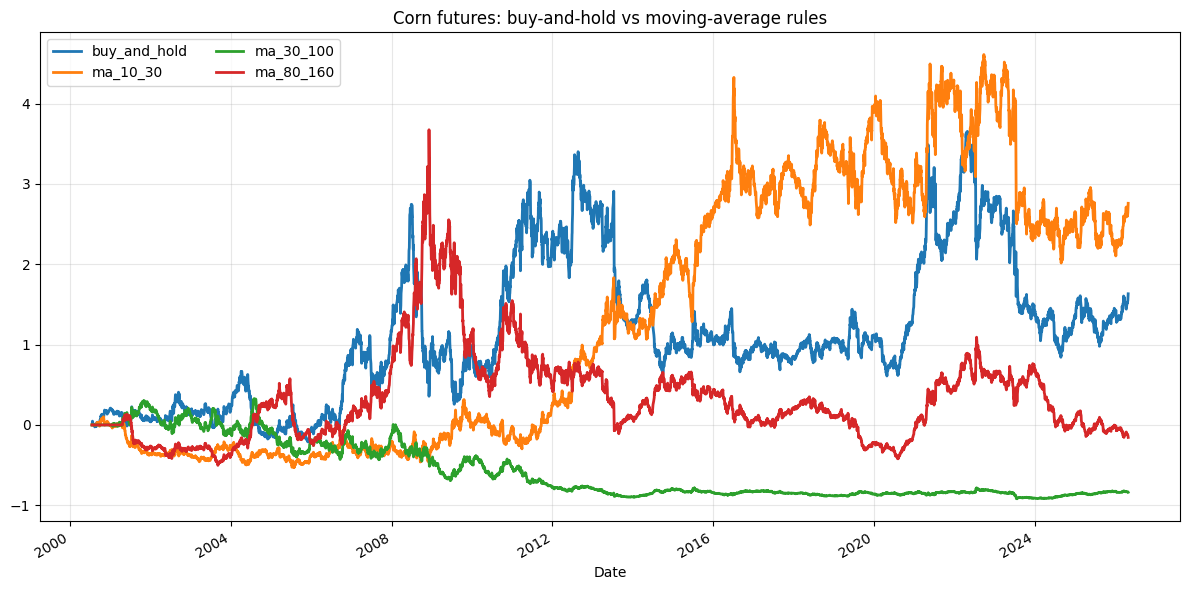

### Interpretation
- The strongest plain moving-average sleeve in this sample is `ma_10_30` with Sharpe 0.32.
- The `30/100` rule will remain the main trend baseline for the first NDVI regime overlay because it matches the course framing most closely.

In [6]:
display(trend_summary)

trend_plot = pd.DataFrame({'buy_and_hold': corn['futures_ret']})
for short_window, long_window in MA_PAIRS:
    trend_plot[f'ma_{short_window}_{long_window}'] = corn[f'strategy_ret_{short_window}_{long_window}']
plot_cumulative_returns(
    trend_plot,
    'Corn futures: buy-and-hold vs moving-average rules',
    figsize=(12, 6),
    ncol=2,
)

best_trend = trend_summary.drop(index='buy_and_hold')['ann_sharpe'].idxmax()
display_bullets(
    'Interpretation',
    [
        f'The strongest plain moving-average sleeve in this sample is `{best_trend}` with Sharpe {trend_summary.loc[best_trend, "ann_sharpe"]:.2f}.',
        'The `30/100` rule will remain the main trend baseline for the first NDVI regime overlay because it matches the course framing most closely.'
    ],
)

## NDVI regime filter on the primary trend rule

Use the NASA regime as a slow overlay on the primary `30/100` trend rule so the notebook shows the regime as more than a standalone signal.

In [7]:
primary_signal = corn_ndvi[f'signal_{PRIMARY_PAIR[0]}_{PRIMARY_PAIR[1]}']
trend_ndvi = build_signal_strategy(
    apply_regime_filter(primary_signal, corn_ndvi['ndvi_regime']),
    corn_ndvi['futures_ret'],
    lag=1,
)
register_strategy('ma_30_100_ndvi', trend_ndvi['strategy_return'], trend_ndvi['signal'])

trend_ndvi_summary = summary_table([
    summarize_strategy('buy_and_hold_overlap', corn_ndvi['futures_ret']),
    summarize_strategy('ndvi_regime', ndvi_strategy['strategy_return'], ndvi_strategy['signal']),
    summarize_strategy('ma_30_100', corn_ndvi['strategy_ret_30_100'], corn_ndvi['signal_30_100']),
    summarize_strategy('ma_30_100_ndvi', trend_ndvi['strategy_return'], trend_ndvi['signal']),
])

## Evaluate NDVI-filtered trend rule

Check whether the NASA regime improves the primary trend sleeve once the two are combined.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold_overlap,6434,1.4893,0.2708,0.3080,-0.6644,NaN
ndvi_regime,6434,19.7722,0.5893,0.2574,-0.5415,0.6782
ma_30_100,6334,-0.8297,-0.0718,0.3096,-0.9389,1.0000
ma_30_100_ndvi,6334,1.8663,0.3016,0.2162,-0.6469,0.5755


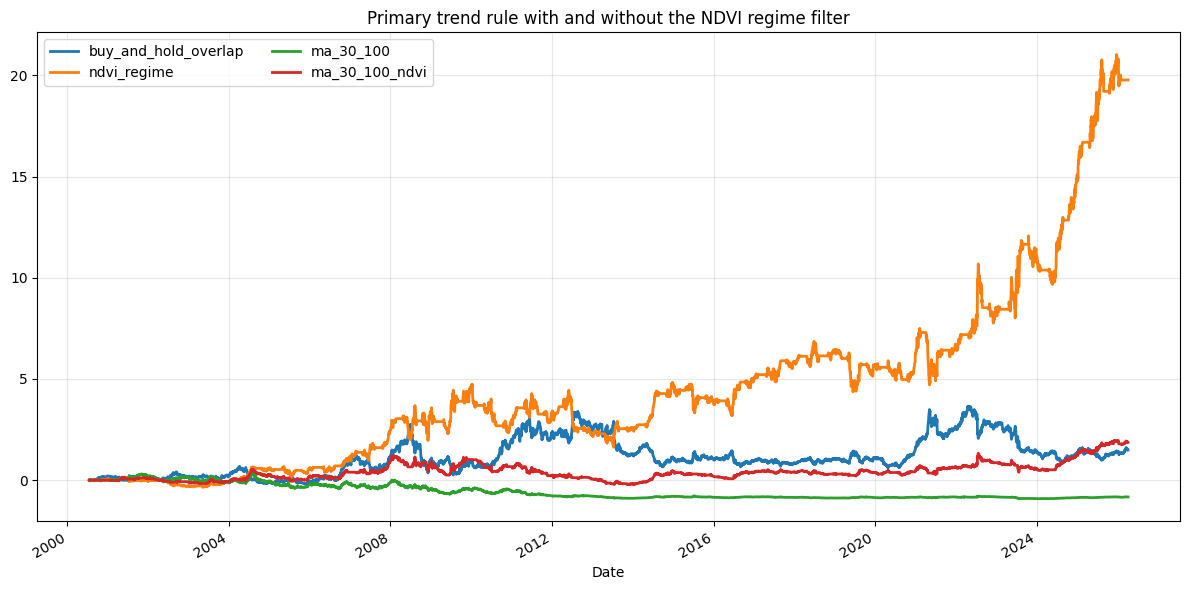

### Interpretation
- The NDVI overlay changes the `30/100` trend Sharpe from -0.07 to 0.30.
- The filter keeps full size when the NASA regime agrees with the trend, cuts size in neutral periods, and blocks the trade when the regime disagrees.

In [8]:
display(trend_ndvi_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'buy_and_hold_overlap': corn_ndvi['futures_ret'],
        'ndvi_regime': ndvi_strategy['strategy_return'],
        'ma_30_100': corn_ndvi['strategy_ret_30_100'],
        'ma_30_100_ndvi': trend_ndvi['strategy_return'],
    }),
    'Primary trend rule with and without the NDVI regime filter',
    figsize=(12, 6),
    ncol=2,
)

display_bullets(
    'Interpretation',
    [
        f'The NDVI overlay changes the `30/100` trend Sharpe from {trend_ndvi_summary.loc["ma_30_100", "ann_sharpe"]:.2f} to {trend_ndvi_summary.loc["ma_30_100_ndvi", "ann_sharpe"]:.2f}.',
        'The filter keeps full size when the NASA regime agrees with the trend, cuts size in neutral periods, and blocks the trade when the regime disagrees.'
    ],
)

## Counter-trend strategy: create

Port the course counter-trend bounce rule into corn futures as its own standalone sleeve.

In [9]:
countertrend = run_countertrend_strategy(corn, p=2.2)
register_strategy('countertrend_p2_2', countertrend['strategy_return'], countertrend['signal'])

countertrend_summary = summary_table([
    summarize_strategy('buy_and_hold', corn['futures_ret']),
    summarize_strategy('countertrend_p2_2', countertrend['strategy_return'], countertrend['signal']),
])

## Counter-trend strategy: evaluate

Measure whether the bounce rule produces a useful standalone sleeve before adding any NASA regime filter.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold,6451,1.6320,0.2776,0.3076,-0.6644,NaN
countertrend_p2_2,6452,0.0373,0.1068,0.1996,-0.7333,0.6046


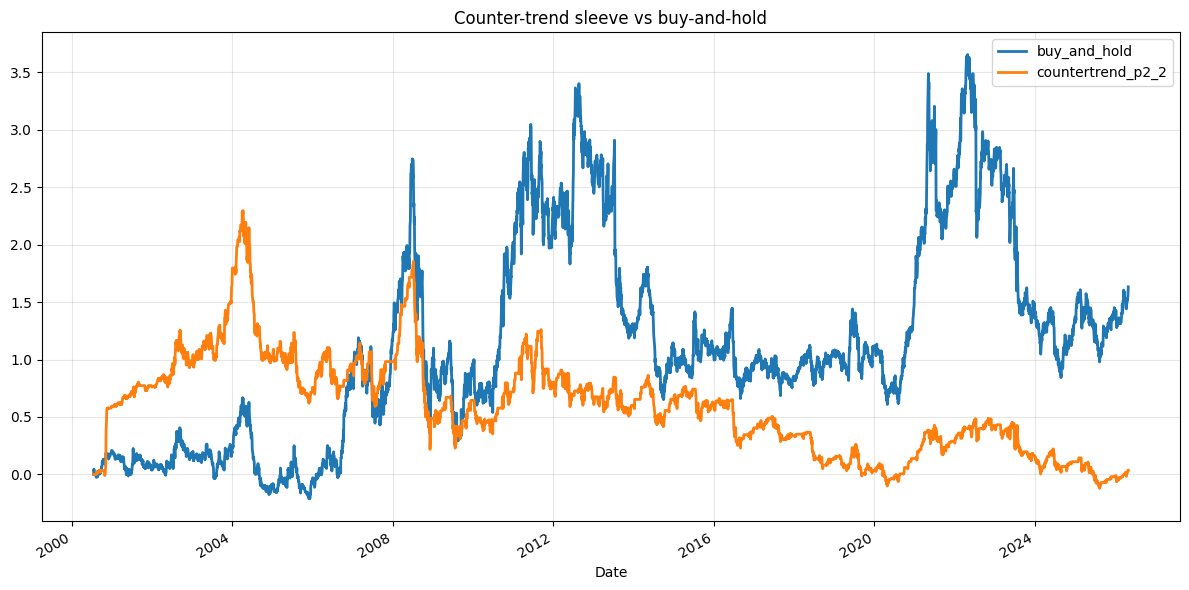

### Interpretation
- The counter-trend rule triggers 3901 long setups in the sample.
- Its annualized Sharpe is 0.11, which is positive but much smaller than the stronger trend sleeves.

In [10]:
display(countertrend_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'buy_and_hold': corn['futures_ret'],
        'countertrend_p2_2': countertrend['strategy_return'],
    }),
    'Counter-trend sleeve vs buy-and-hold',
    figsize=(12, 6),
    ncol=1,
)

trade_count = int(countertrend['signal'].sum())
display_bullets(
    'Interpretation',
    [
        f'The counter-trend rule triggers {trade_count} long setups in the sample.',
        f'Its annualized Sharpe is {countertrend_summary.loc["countertrend_p2_2", "ann_sharpe"]:.2f}, which is positive but much smaller than the stronger trend sleeves.'
    ],
)

## NDVI regime filter on counter-trend

Apply the NDVI regime to the counter-trend sleeve so the NASA data is not tied only to the trend family.

In [11]:
countertrend_ndvi_panel = countertrend.join(corn_ndvi[['ndvi_regime']], how='inner')
countertrend_ndvi_panel['filtered_signal'] = apply_regime_filter(countertrend_ndvi_panel['signal'], countertrend_ndvi_panel['ndvi_regime'])
countertrend_ndvi_panel['filtered_return'] = countertrend_ndvi_panel['strategy_return'].fillna(0.0) * countertrend_ndvi_panel['filtered_signal'].fillna(0.0)
register_strategy('countertrend_p2_2_ndvi', countertrend_ndvi_panel['filtered_return'], countertrend_ndvi_panel['filtered_signal'])

countertrend_ndvi_summary = summary_table([
    summarize_strategy('buy_and_hold_overlap', corn_ndvi['futures_ret']),
    summarize_strategy('countertrend_p2_2', countertrend_ndvi_panel['strategy_return'], countertrend_ndvi_panel['signal']),
    summarize_strategy('countertrend_p2_2_ndvi', countertrend_ndvi_panel['filtered_return'], countertrend_ndvi_panel['filtered_signal']),
])

## Evaluate NDVI-filtered counter-trend

See whether crop stress adds value as a regime gate on the intraday bounce rule.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold_overlap,6434,1.4893,0.2708,0.3080,-0.6644,NaN
countertrend_p2_2,6435,0.0120,0.1021,0.1997,-0.7333,0.604
countertrend_p2_2_ndvi,6435,5.0078,0.6788,0.1128,-0.3749,0.269


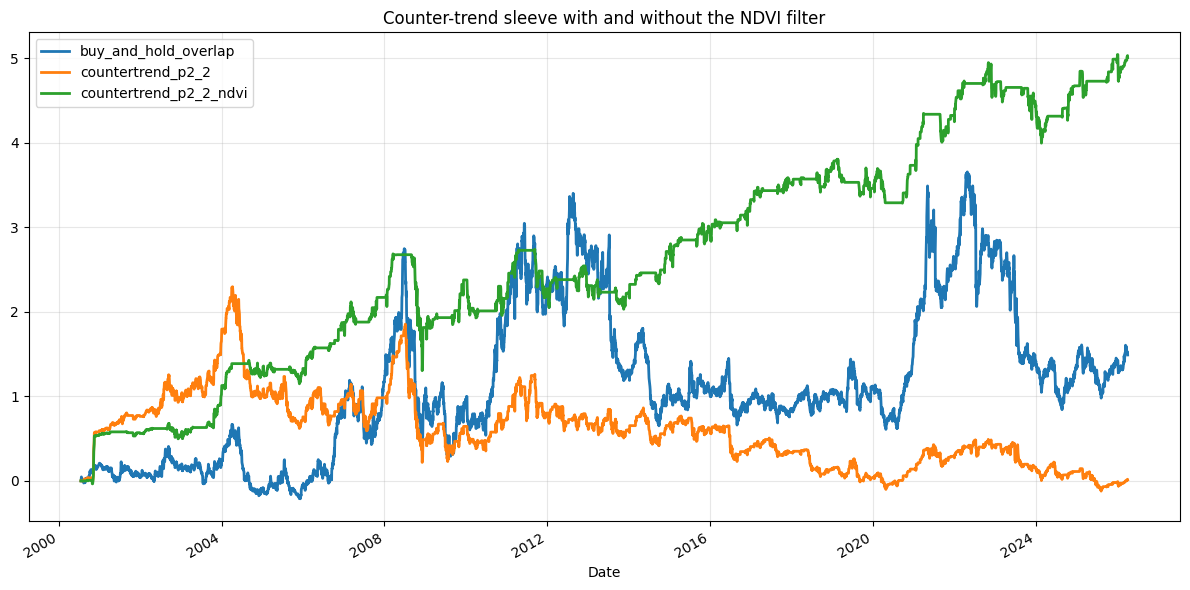

### Interpretation
- The NDVI overlay changes the counter-trend Sharpe from 0.10 to 0.68.
- Because the counter-trend rule is long-only, a bearish NDVI regime removes trades while a neutral regime scales them down.

In [12]:
display(countertrend_ndvi_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'buy_and_hold_overlap': corn_ndvi['futures_ret'],
        'countertrend_p2_2': countertrend_ndvi_panel['strategy_return'],
        'countertrend_p2_2_ndvi': countertrend_ndvi_panel['filtered_return'],
    }),
    'Counter-trend sleeve with and without the NDVI filter',
    figsize=(12, 6),
    ncol=1,
)

display_bullets(
    'Interpretation',
    [
        f'The NDVI overlay changes the counter-trend Sharpe from {countertrend_ndvi_summary.loc["countertrend_p2_2", "ann_sharpe"]:.2f} to {countertrend_ndvi_summary.loc["countertrend_p2_2_ndvi", "ann_sharpe"]:.2f}.',
        'Because the counter-trend rule is long-only, a bearish NDVI regime removes trades while a neutral regime scales them down.'
    ],
)

## Volatility regime strategy: create

Build the volatility-regime sleeve as a separate directional strategy and keep it distinct from the NASA regime signal.

In [13]:
vol_regime = run_vol_regime_strategy(corn)
register_strategy('vol_regime', vol_regime['strategy_return'], vol_regime['signal'])

vol_summary = summary_table([
    summarize_strategy('buy_and_hold', corn['futures_ret']),
    summarize_strategy('vol_regime', vol_regime['strategy_return'], vol_regime['signal']),
])

## Volatility regime strategy: evaluate

Check whether the course volatility regime rule is interesting on its own before layering the NASA regime on top.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold,6451,1.6320,0.2776,0.3076,-0.6644,NaN
vol_regime,6181,10.0235,0.4711,0.3108,-0.5660,1.0


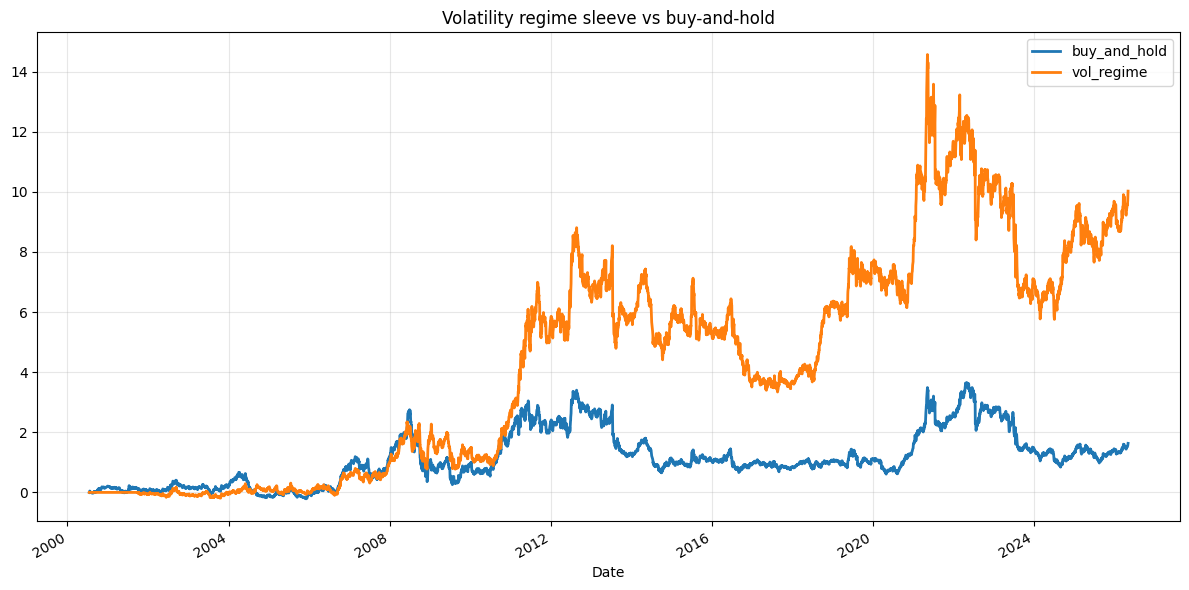

### Interpretation
- The volatility rule is long 82.0% of observed days and short 13.8%.
- Its annualized Sharpe is 0.47, making it one of the stronger standalone sleeves in the current sample.

In [14]:
display(vol_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'buy_and_hold': corn['futures_ret'],
        'vol_regime': vol_regime['strategy_return'],
    }),
    'Volatility regime sleeve vs buy-and-hold',
    figsize=(12, 6),
    ncol=1,
)

long_share = pd.Series(vol_regime['signal']).eq(1.0).mean()
short_share = pd.Series(vol_regime['signal']).eq(-1.0).mean()
display_bullets(
    'Interpretation',
    [
        f'The volatility rule is long {long_share:.1%} of observed days and short {short_share:.1%}.',
        f'Its annualized Sharpe is {vol_summary.loc["vol_regime", "ann_sharpe"]:.2f}, making it one of the stronger standalone sleeves in the current sample.'
    ],
)

## NDVI regime filter on volatility regime

Apply the NDVI overlay to a second directional family so the regime can be compared across multiple base strategies.

In [15]:
vol_ndvi = build_signal_strategy(
    apply_regime_filter(vol_regime['signal'].reindex(corn_ndvi.index), corn_ndvi['ndvi_regime']),
    corn_ndvi['futures_ret'],
    lag=1,
)
register_strategy('vol_regime_ndvi', vol_ndvi['strategy_return'], vol_ndvi['signal'])

vol_ndvi_summary = summary_table([
    summarize_strategy('buy_and_hold_overlap', corn_ndvi['futures_ret']),
    summarize_strategy('vol_regime', vol_regime['strategy_return'].reindex(corn_ndvi.index), vol_regime['signal'].reindex(corn_ndvi.index)),
    summarize_strategy('vol_regime_ndvi', vol_ndvi['strategy_return'], vol_ndvi['signal']),
])

## Evaluate NDVI-filtered volatility regime

Measure whether the NASA regime improves the volatility sleeve in the same way it can improve trend or counter-trend signals.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
buy_and_hold_overlap,6434,1.4893,0.2708,0.3080,-0.6644,NaN
vol_regime,6164,9.4256,0.4645,0.3111,-0.5660,1.0000
vol_regime_ndvi,6164,26.0977,0.8319,0.1820,-0.3284,0.5129


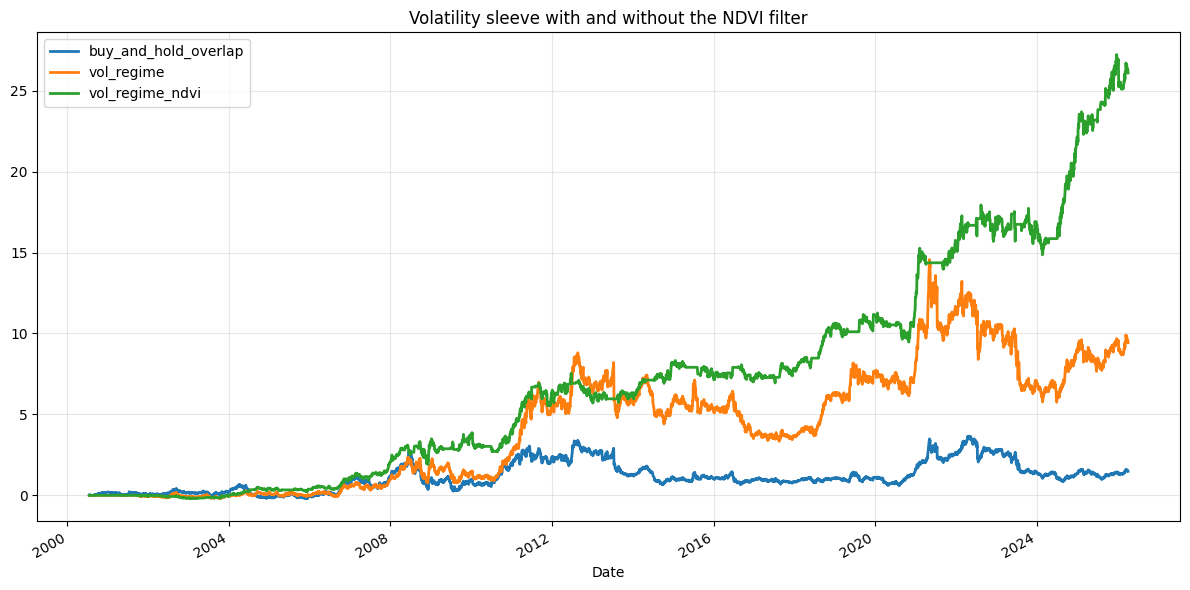

### Interpretation
- The NDVI overlay changes the volatility-regime Sharpe from 0.46 to 0.83.
- This makes it easy to compare whether the same slow regime helps multiple directional strategy families or only one of them.

In [16]:
display(vol_ndvi_summary)

plot_cumulative_returns(
    pd.DataFrame({
        'buy_and_hold_overlap': corn_ndvi['futures_ret'],
        'vol_regime': vol_regime['strategy_return'].reindex(corn_ndvi.index),
        'vol_regime_ndvi': vol_ndvi['strategy_return'],
    }),
    'Volatility sleeve with and without the NDVI filter',
    figsize=(12, 6),
    ncol=1,
)

display_bullets(
    'Interpretation',
    [
        f'The NDVI overlay changes the volatility-regime Sharpe from {vol_ndvi_summary.loc["vol_regime", "ann_sharpe"]:.2f} to {vol_ndvi_summary.loc["vol_regime_ndvi", "ann_sharpe"]:.2f}.',
        'This makes it easy to compare whether the same slow regime helps multiple directional strategy families or only one of them.'
    ],
)

## Pairs study: test stationarity

Before building a pairs trade, test whether the corn-wheat spread behaves like a potentially mean-reverting series.

,value
df_tstat_regression,-4.4650
adf_stat,-3.9752
pvalue,0.0015
critical_10pct,-2.5670
critical_5pct,-2.8620
critical_1pct,-3.4314
observations,6412.0000


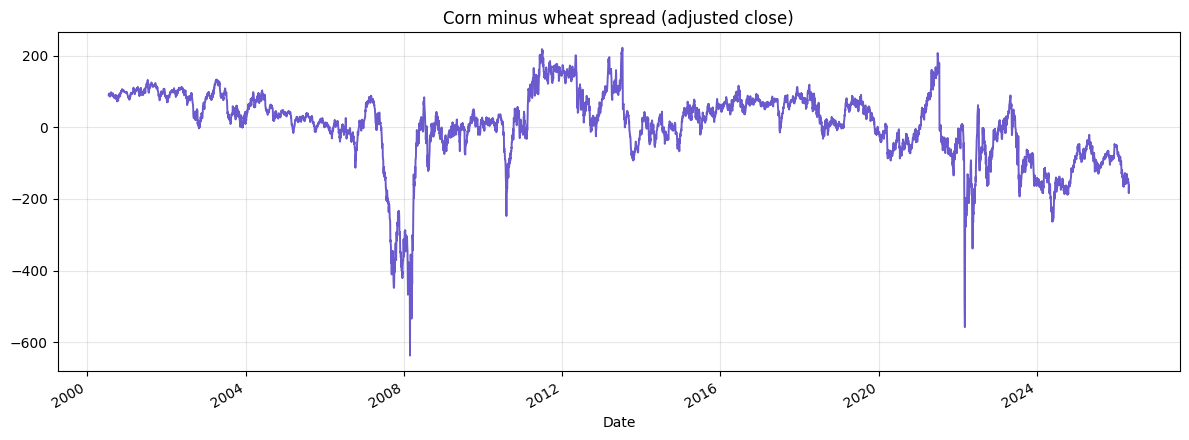

In [17]:
pairs_panel = pd.DataFrame()
pairs_diagnostics = None
pairs_strategy_summary = pd.DataFrame()

if wheat is None:
    display_bullets(
        'Pairs section skipped',
        ['The wheat futures cache is missing, so no pairs study can be run in this notebook pass.'],
    )
else:
    pairs_panel = build_pairs_panel(corn, wheat, horizons=PAIRS_HORIZONS)
    pairs_diagnostics = dickey_fuller_diagnostics(pairs_panel['spread_price'])
    display(pd.DataFrame([pairs_diagnostics]).T.rename(columns={0: 'value'}).round(4))

    fig, ax = plt.subplots(figsize=(12, 4.5))
    pairs_panel['spread_price'].plot(ax=ax, color='slateblue', linewidth=1.4)
    ax.set_title('Corn minus wheat spread (adjusted close)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Pairs study: interpretation

Use the Dickey-Fuller result as a gate. A stationary-looking spread makes a pairs trade worth testing, but it does not guarantee a good realized Sharpe.

In [18]:
if pairs_diagnostics is not None:
    stationary = pairs_diagnostics['pvalue'] < 0.05
    display_bullets(
        'Dickey-Fuller interpretation',
        [
            f'ADF p-value = {pairs_diagnostics["pvalue"]:.4f}.',
            'This sample supports the idea that the corn-wheat spread is stationary enough to justify a pairs test.' if stationary else 'This sample does not provide strong evidence that the spread is stationary, so any pairs results should be treated cautiously.',
            'The next section still matters more than the test itself because realized trade performance is the real decision variable.'
        ],
    )

### Dickey-Fuller interpretation
- ADF p-value = 0.0015.
- This sample supports the idea that the corn-wheat spread is stationary enough to justify a pairs test.
- The next section still matters more than the test itself because realized trade performance is the real decision variable.

## Pairs strategy: build and run

Run the 5-day, 10-day, and 20-day pairs versions once the spread diagnostic is in place.

In [19]:
if not pairs_panel.empty:
    pairs_rows = []
    for horizon in PAIRS_HORIZONS:
        result = run_pairs_position_strategy(pairs_panel[f'zdiff{horizon}'], pairs_panel['future_spread_ret'])
        pairs_panel[f'pairs_ret_{horizon}'] = result['strategy_return']
        pairs_panel[f'pairs_pos_{horizon}'] = result['position']
        name = f'pairs_{horizon}d'
        register_strategy(name, pairs_panel[f'pairs_ret_{horizon}'], pairs_panel[f'pairs_pos_{horizon}'])
        pairs_rows.append(summarize_strategy(name, pairs_panel[f'pairs_ret_{horizon}'], pairs_panel[f'pairs_pos_{horizon}']))
    pairs_strategy_summary = summary_table(pairs_rows, sort=True)

## Pairs strategy: evaluate

Compare the three holding horizons and decide whether the pairs idea is compelling enough to keep in the final sleeve comparison.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
pairs_5d,6415,0.0946,0.0905,0.1235,-0.4136,0.4882
pairs_10d,6415,0.0550,0.0784,0.1228,-0.4013,0.4737
pairs_20d,6415,-0.4835,-0.1459,0.1247,-0.6430,0.4842


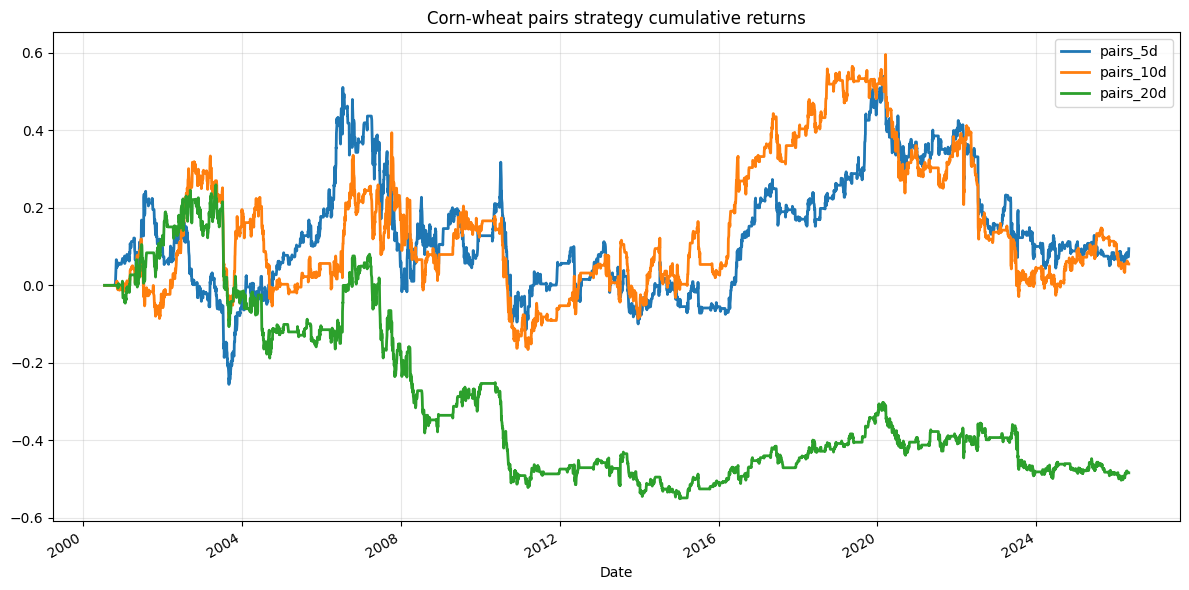

### Interpretation
- The best pairs horizon in this sample is `pairs_5d` with Sharpe 0.09.
- Even with a favorable stationarity test, the pairs sleeve still needs realized Sharpe and drawdown behavior that justify keeping it in the final comparison.

In [20]:
if pairs_strategy_summary.empty:
    display_bullets('Pairs evaluation', ['No pairs strategy results are available because the pairs section was skipped.'])
else:
    display(pairs_strategy_summary)
    plot_cumulative_returns(
        pd.DataFrame({
            'pairs_5d': pairs_panel['pairs_ret_5'],
            'pairs_10d': pairs_panel['pairs_ret_10'],
            'pairs_20d': pairs_panel['pairs_ret_20'],
        }),
        'Corn-wheat pairs strategy cumulative returns',
        figsize=(12, 6),
        ncol=1,
    )

    best_pairs = pairs_strategy_summary['ann_sharpe'].idxmax()
    display_bullets(
        'Interpretation',
        [
            f'The best pairs horizon in this sample is `{best_pairs}` with Sharpe {pairs_strategy_summary.loc[best_pairs, "ann_sharpe"]:.2f}.',
            'Even with a favorable stationarity test, the pairs sleeve still needs realized Sharpe and drawdown behavior that justify keeping it in the final comparison.'
        ],
    )

## Compare all strategy sleeves

At this point the notebook has treated the NASA regime as both a standalone signal and a reusable overlay. Now compare every sleeve on the same summary grid before deciding which ones deserve inclusion in a combined portfolio.

,obs,cum_return,ann_sharpe,ann_vol,max_drawdown,active_share
strategy,,,,,,
vol_regime_ndvi,6164,26.0977,0.8319,0.1820,-0.3284,0.5129
countertrend_p2_2_ndvi,6435,5.0078,0.6788,0.1128,-0.3749,0.2690
ndvi_regime,6434,19.7722,0.5893,0.2574,-0.5415,0.6782
vol_regime,6181,10.0235,0.4711,0.3108,-0.5660,1.0000
ma_10_30,6421,2.7582,0.3231,0.3082,-0.5738,1.0000
ma_30_100_ndvi,6334,1.8663,0.3016,0.2162,-0.6469,0.5755
buy_and_hold,6451,1.6320,0.2776,0.3076,-0.6644,NaN
ma_80_160,6291,-0.1554,0.1340,0.3103,-0.8763,1.0000
countertrend_p2_2,6452,0.0373,0.1068,0.1996,-0.7333,0.6046


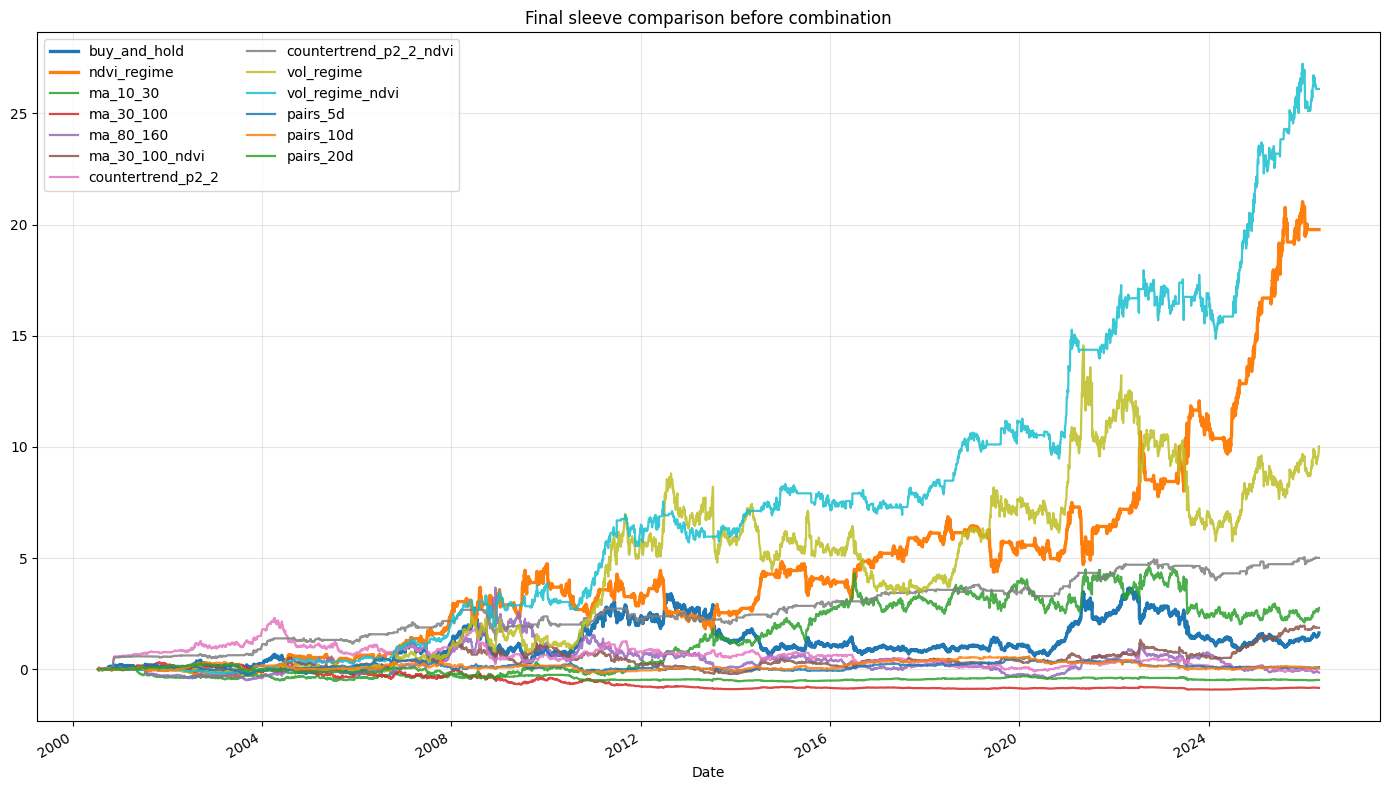

### Comparison takeaway
- The highest standalone Sharpe in the current notebook pass belongs to `vol_regime_ndvi` at 0.83.
- The NASA NDVI regime now appears twice in the study: once as its own signal and again as a reusable filter across multiple directional strategy families.
- The next step is to decide which sleeves are robust enough to include in the final combined portfolio.

In [21]:
comparison_summary = pd.DataFrame(strategy_summary_map.values()).set_index('strategy').sort_values('ann_sharpe', ascending=False).round(4)
display(comparison_summary)

comparison_returns = pd.DataFrame(strategy_return_streams).sort_index()
comparison_plot_order = [
    'buy_and_hold',
    'ndvi_regime',
    'ma_10_30',
    'ma_30_100',
    'ma_80_160',
    'ma_30_100_ndvi',
    'countertrend_p2_2',
    'countertrend_p2_2_ndvi',
    'vol_regime',
    'vol_regime_ndvi',
    'pairs_5d',
    'pairs_10d',
    'pairs_20d',
]
comparison_plot_order = [name for name in comparison_plot_order if name in comparison_returns.columns]

fig, ax = plt.subplots(figsize=(14, 8))
for name in comparison_plot_order:
    linewidth = 2.4 if name in {'buy_and_hold', 'ndvi_regime'} else 1.6
    alpha = 1.0 if name in {'buy_and_hold', 'ndvi_regime'} else 0.85
    cumulative_return(comparison_returns[name]).plot(ax=ax, label=name, linewidth=linewidth, alpha=alpha)
ax.set_title('Final sleeve comparison before combination')
ax.grid(True, alpha=0.3)
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

best_strategy = comparison_summary.index[0]
display_bullets(
    'Comparison takeaway',
    [
        f'The highest standalone Sharpe in the current notebook pass belongs to `{best_strategy}` at {comparison_summary.iloc[0]["ann_sharpe"]:.2f}.',
        'The NASA NDVI regime now appears twice in the study: once as its own signal and again as a reusable filter across multiple directional strategy families.',
        'The next step is to decide which sleeves are robust enough to include in the final combined portfolio.'
    ],
)

## Notes

- This notebook remains intentionally strategy-only. If a required CSV is missing, rebuild it in the appropriate data-builder notebook first.
- The Sharpe ratio used throughout is the simple annualized mean-over-volatility metric with no market or beta subtraction.
- The combination step is intentionally deferred so the present notebook can focus on strategy creation, evaluation, and presentation.